## Pergunta 1 — Valor Total Recebido por Mês (Jan–Mai 2023)

**Pergunta:** Qual foi o valor total recebido pelos motoristas de táxi amarelo em NYC por mês?

**Fonte de dados:** Delta Table `ifood_taxi_case.taxi_gold` (Camada de consumo do Lakehouse).

### a) Setup

In [0]:
%load_ext autoreload
%autoreload 2

import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.config.settings import Tables

print(f"Tabela: {Tables.SCHEMA}.{Tables.GOLD_TAXI}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Tabela: ifood_taxi_case.taxi_gold


### b) Critério de Filtro: `total_amount > 0`

Corridas com `total_amount <= 0` representam:
- chargebacks (`payment_type = 4 — Dispute`)
- corridas sem cobrança (`payment_type 3 — No charge / 6 - Voided trip`). 

Não constituem receita efetiva para os motoristas e são excluídas da agregação mensal.

In [0]:
%sql
SELECT
    year,
    month,
    COUNT(*)                    AS total_trips,
    ROUND(SUM(total_amount), 2) AS total_amount_received
FROM ifood_taxi_case.taxi_gold
WHERE total_amount > 0
GROUP BY year, month
ORDER BY year, month

year,month,total_trips,total_amount_received
2023,1,3019020,8.293597322E7
2023,2,2866496,7.844213126E7
2023,3,3346691,9.469830485E7
2023,4,3231438,9.302967564E7
2023,5,3452896,1.0183923827E8


### c) Visualização e Conclusão

In [0]:
%sql
WITH monthly AS (
    SELECT
        month,
        SUM(total_amount) AS total,
        AVG(total_amount) AS avg_ticket
    FROM ifood_taxi_case.taxi_gold
    WHERE total_amount > 0
    GROUP BY month
),

base as (
SELECT
    CASE month
        WHEN 1 THEN 'Jan'
        WHEN 2 THEN 'Fev'
        WHEN 3 THEN 'Mar'
        WHEN 4 THEN 'Abr'
        WHEN 5 THEN 'Mai'
    END                                         AS mes,
    CONCAT('$', ROUND(total / 1000000, 1), 'M') AS receita_total,
    CONCAT('$', ROUND(avg_ticket, 2))           AS ticket_medio,
    month                                        AS sort_order
FROM monthly

UNION ALL

SELECT
    'Média do período',
    CONCAT('$', ROUND(AVG(total) / 1000000, 1), 'M'),
    CONCAT('$', ROUND(AVG(avg_ticket), 2)),
    99
FROM monthly

ORDER BY sort_order
)

SELECT * EXCEPT(sort_order) FROM base

mes,receita_total,ticket_medio
Jan,$82.9M,$27.47
Fev,$78.4M,$27.37
Mar,$94.7M,$28.3
Abr,$93.0M,$28.79
Mai,$101.8M,$29.49
Média do período,$90.2M,$28.28


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


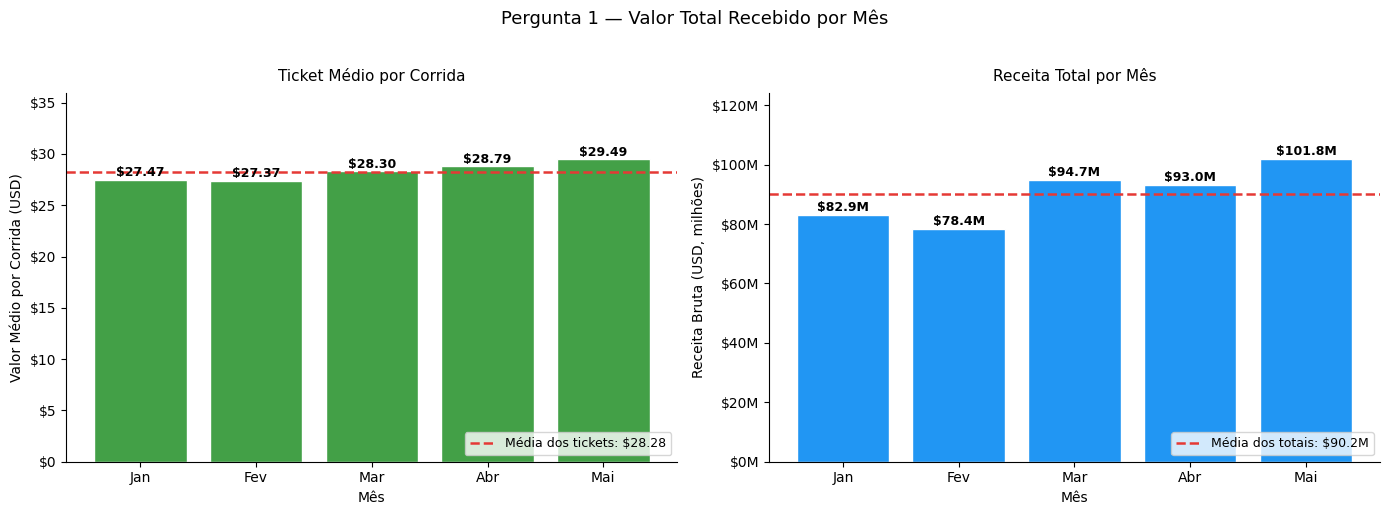

In [0]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Queries 
df_sum = spark.sql("""
    SELECT month, SUM(total_amount) AS monthly_total
    FROM ifood_taxi_case.taxi_gold
    WHERE total_amount > 0
    GROUP BY month ORDER BY month
""").toPandas()

df_avg = spark.sql("""
    SELECT month, AVG(total_amount) AS avg_trip_amount
    FROM ifood_taxi_case.taxi_gold
    WHERE total_amount > 0
    GROUP BY month ORDER BY month
""").toPandas()

month_labels  = ["Jan", "Fev", "Mar", "Abr", "Mai"]
sums          = df_sum["monthly_total"] / 1_000_000
avgs          = df_avg["avg_trip_amount"]
avg_sum_line  = sums.mean()
avg_avg_line  = avgs.mean()

# Subplot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Pergunta 1 — Valor Total Recebido por Mês", fontsize=13, y=1.02)

# Ticket medio por mês
bars1 = ax1.bar(month_labels, avgs, color="#43A047", edgecolor="white")
ax1.axhline(avg_avg_line, color="#E53935", linewidth=1.8, linestyle="--",
            label=f"Média dos tickets: ${avg_avg_line:.2f}")
for bar, val in zip(bars1, avgs):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
             f"${val:.2f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax1.set_title("Ticket Médio por Corrida", fontsize=11, pad=8)
ax1.set_xlabel("Mês"); ax1.set_ylabel("Valor Médio por Corrida (USD)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}"))
ax1.set_ylim(0, max(avgs) * 1.22)
ax1.legend(fontsize=9, loc="lower right")
ax1.spines[["top", "right"]].set_visible(False)

# Receita por mes
bars2 = ax2.bar(month_labels, sums, color="#2196F3", edgecolor="white")
ax2.axhline(avg_sum_line, color="#E53935", linewidth=1.8, linestyle="--",
            label=f"Média dos totais: ${avg_sum_line:.1f}M")
for bar, val in zip(bars2, sums):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f"${val:.1f}M", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax2.set_title("Receita Total por Mês", fontsize=11, pad=8)
ax2.set_xlabel("Mês"); ax2.set_ylabel("Receita Bruta (USD, milhões)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}M"))
ax2.set_ylim(0, max(sums) * 1.22)
ax2.legend(fontsize=9, loc="lower right")
ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show() 

### c) Conclusão — Quatro Perspectivas sobre o Valor Recebido por Mês

| Perspectiva | Query | Foco |
|-------------|-------|------|
| **Receita total por mês** | `SUM(total_amount)` | Quanto circulou no mercado em cada mês — volume absoluto e sazonalidade |
| **Média dos totais mensais** | `AVG(SUM por mês)` | Receita esperada em um mês típico do período (linha vermelha, Gráfico 1) |
| **Ticket médio por corrida** | `AVG(total_amount)` | Quanto vale cada corrida individual — independente do volume total de viagens |
| **Média dos tickets médios** | `AVG(AVG por mês)` | Ticket médio esperado em um mês típico do período (linha vermelha, Gráfico 2) |

. 

#### **A média de valor total (ticket médio) por corrida foi de $28,28 para o período analisado. Para referência, a média de faturamento mensal foi de $90,2M (média dos totais mensais).**

- **Ticket médio:** Demonstrou uma `média de $28.28`, considerando todo o periodo analisado com `minima de $27.7 em Janeiro` e `máxima de $29.49 em Maio` apresentando uma tendencia de crescimento
- **Faturamento:** Demonstrou uma `média de $90.2M`, considerando todo o periodo analisado com `minima de $78.4 em Fevereiro` e `máxima de $101.8M em Maio`. Há oscilações importantes entre os meses do periodo, os detalhes foram comentados na seçao abaixo.

**Destaques:**
- **Maio** registra o `maior total absoluto ($101.8M)` e tende a ter o `maior ticket médio ($29.49)` — indica não apenas mais
  corridas, mas corridas mais longas ou em zonas de maior tarifa (recuperação pós-inverno).
- **Fevereiro** apresenta a `menor receita ($78.4M)`, explicado em grande parte pelo menor número de dias do mês
  (28 dias vs. 31). Porem, o `ticket médio ($27.37) por corrida se mantem estável`.
- As **linhas de referência** nos dois gráficos permitem identificar rapidamente quais meses
  performaram acima ou abaixo do esperado para o período em cada dimensão.